# Target Tracking for Contextual Bandits: Application to Demand Side Management

***Summer School - June, 29 2026***

This notebook is based on the paper *Target tracking for contextual bandits: Application to demand side management*. M Brégère, P Gaillard, Y Goude, G Stoltz - International Conference on Machine Learning, 2019.

We consider [open data](https://data.london.gov.uk/dataset/smartmeter-energy-consumption-data-in-london-households-vqm0d/) published by UK Power Networks and containing energy consumption (in kWh per half-hour) of approximately 1 100 customers subjected to dynamic time of use energy prices. The tariffs, among High (67.20 p/kWh), Low (3.99p/kWh) or normal (11.76 p/kWh), and the times of day these applied (at half-hourly intervals) were offered to all customers and were announced a day ahead via the smart meter or by text message to mobile phone. 

In [1]:
import numpy as np
import pandas as pd
import random
import math
import visualization_functions

### Data analysis and electrical demand modelling

In [2]:
data = pd.read_csv('electrical_demand_data.csv', index_col = 'date_time')
data.index = pd.to_datetime(data.index, format='mixed')
data.head()

,demand,temperature,day,half_hour,position_in_the_year,tariff
date_time,,,,,,
2013-01-01 00:00:00,0.220407,9.44,Tuesday,0,0.000000,Normal
2013-01-01 00:30:00,0.204810,9.44,Tuesday,1,0.000057,Normal
2013-01-01 01:00:00,0.189348,9.44,Tuesday,2,0.000114,Normal
2013-01-01 01:30:00,0.172589,9.44,Tuesday,3,0.000171,Normal
2013-01-01 02:00:00,0.155130,9.44,Tuesday,4,0.000228,Normal


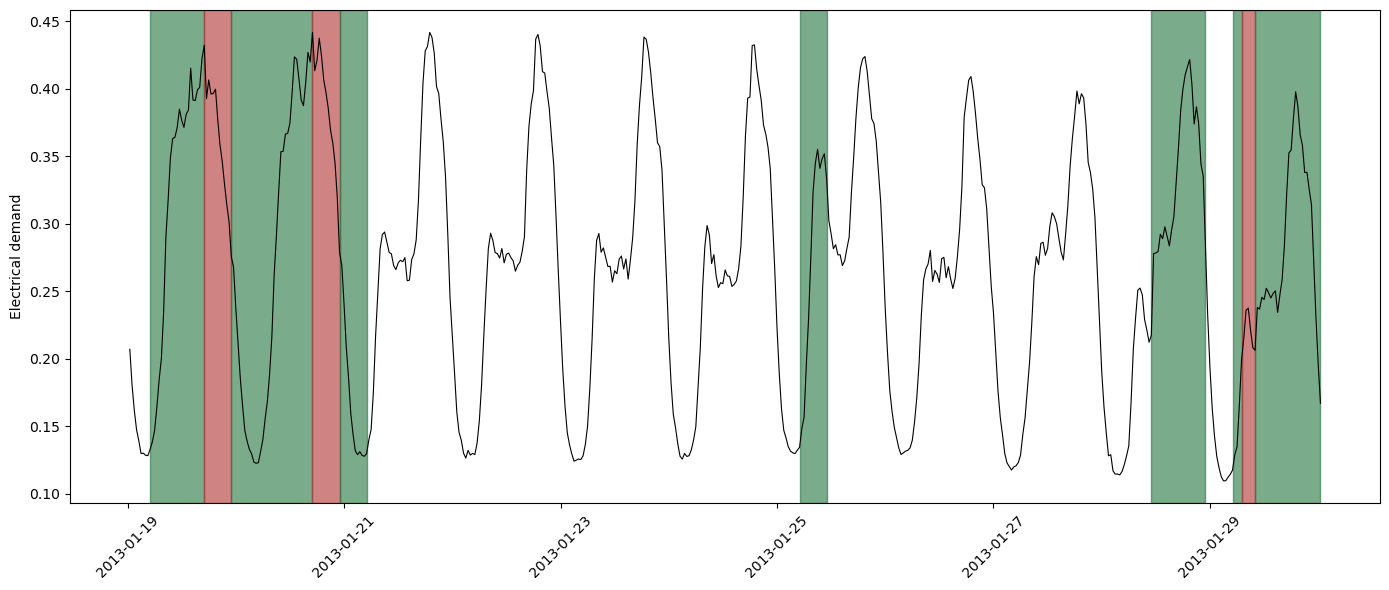

In [3]:
visualization_functions.plot_demand(data, deb = '2013-01-19 00:30:00', end= '2013-01-30 00:30:00') # January 19, 2023 is a Saturday.

$$Y_{t,p_t} = \phi(X_t,p_t)^\mathrm{T}\theta + \varepsilon_t $$

We define below a mapping function $\phi$. In order to simplify the code and execution, we separate the context part from the price part. We will calculate the context-related mapping once and for all, without loss of generality. This simplifies normalisation, one-hot encoding, smoothed temperature calculation, etc.

The normalisation ensures that for any $x\in\mathcal{X}$ and $p \in \mathcal{P}$, $\|\phi(x,p)\|_\infty \leq 1$


In [4]:
prices = pd.get_dummies(data['tariff'], prefix= 'tariff')*1 
prices= prices.loc[:, ['tariff_High', 'tariff_Normal', 'tariff_Low']] 
prices[['tariff_High', 'tariff_Normal', 'tariff_Low']] = prices[['tariff_High', 'tariff_Normal', 'tariff_Low']].astype(float)
context = data.drop(['tariff','demand'], axis = 1)

def mapping_context(context):
    # one-hot encoding of binary variables
    # df = pd.concat([context, 
    #                 pd.get_dummies(data['day'], drop_first = True)*1,  
    #                 pd.get_dummies(data['half_hour'], prefix='half_hour', drop_first = True)*1], axis=1).drop(['day','half_hour'], axis=1)
    
    day_halfhour = context['day'].astype(str) + '_' + context['half_hour'].astype(str)
    df = pd.get_dummies(day_halfhour,  prefix='day_halfhour', drop_first=True).astype(int)
    
    # year_seasonality : with sosinus, 31 December and 1 January are next to each other.   
    df['year_seasonality'] = np.cos(2 * np.pi * np.arange(0, len(df))/ (365*48))

    # temperature inertia modeling
    def exp_smooth(vec, alpha):
        if alpha > 1 or alpha < 0:
            return 'alpha doit etre compris entre 0 et 1'
        else:
            smth = np.full(len(vec), np.nan)
            if len(vec) > 0:
                smth[0] = vec[0]
                if len(vec) > 1:
                    for i in range(1, len(vec)):
                        smth[i] = alpha * smth[i - 1] + (1 - alpha) * vec[i]
            return smth

    df['smoothed_temperature'] = exp_smooth(context['temperature'].to_numpy(), alpha= 0.998)    
    
    # potential non-linearity for temperature 
    df['heating_temperature2'] = (context['temperature'])**2 
    # df['heating_heating'] = (context['temperature']<10)*(context['temperature'])
    # df['heating_ac'] = (context['temperature']>20)*(context['temperature'])
    
    # temperature per half_hour 
    temp_by_halfhour = pd.get_dummies(context['half_hour'], prefix='temp_half_hour', drop_first=False).mul(context['temperature'], axis=0)
    df = pd.concat([df, temp_by_halfhour], axis=1)
    df_n = df.max(axis=0)
    return df/df_n

def mapping_prices(prices, context_map = None):
    # potential non-linear prices modelling, with possible relationship with context
    # ...
    return prices


In [5]:
context_map = mapping_context(context)
phi = pd.concat([mapping_prices(prices), context_map], axis=1)
y = data['demand'].to_numpy()
theta = np.linalg.pinv(phi.to_numpy()) @ y
theta = pd.Series(theta, index=phi.columns)
theta_context = theta[3:]
theta_prices = theta[:3]

In [6]:
# Metrics
def mape(y, y_hat, eps=1e-5):
    return 100 * np.mean(np.abs((y_hat - y) / (np.abs(y) + eps)))
def rmse(y, y_hat):
    return np.mean((y_hat - y)**2)

forecast = phi @ theta
print('MAPE: ', round(mape(y, forecast), 2), '%')
print('RMSE: ', round(rmse(y*1000, forecast*1000),0), '(hWh/half-hour)\n')

MAPE:  6.81 %
RMSE:  306.0 (hWh/half-hour)



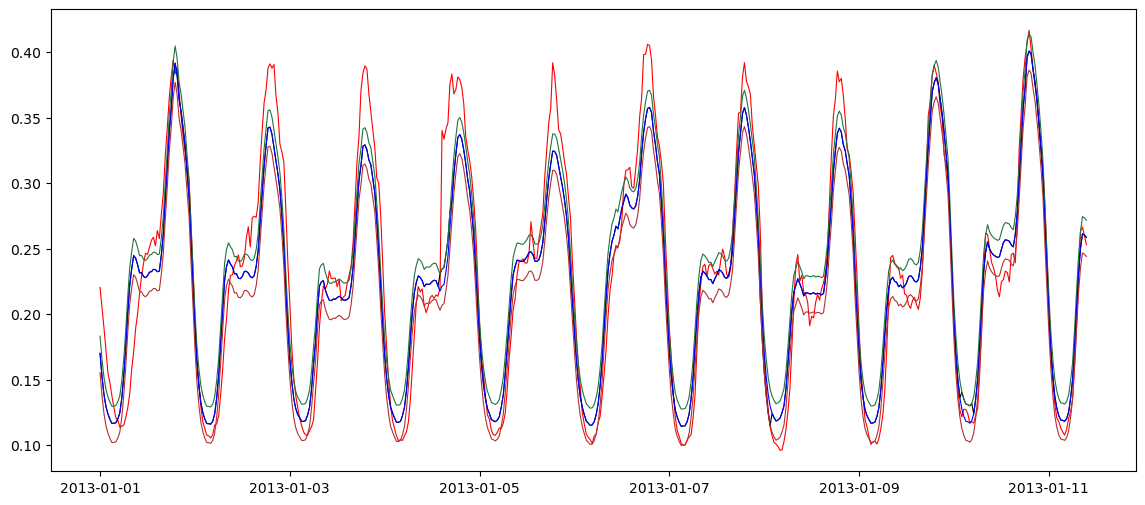

In [7]:
prices_Low = prices.copy()
prices_Low['tariff_High'] = 0
prices_Low['tariff_Normal'] = 0
prices_Low['tariff_Low'] = 1

prices_Normal = prices.copy()
prices_Normal['tariff_High'] = 0
prices_Normal['tariff_Normal'] = 1
prices_Normal['tariff_Low'] = 0

prices_High = prices.copy()
prices_High['tariff_High'] = 1
prices_High['tariff_Normal'] = 0
prices_High['tariff_Low'] = 0

phi_Low = pd.concat([mapping_prices(prices_Low), context_map], axis=1)
phi_Normal = pd.concat([mapping_prices(prices_Normal), context_map], axis=1)
phi_High = pd.concat([mapping_prices(prices_High), context_map], axis=1)

forecast_Low = phi_Low @ theta
forecast_Normal = phi_Normal @ theta
forecast_High = phi_High @ theta

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(phi.index[0:n], y[0:n], color='red', linewidth=0.8)
ax.plot(phi.index[0:n], forecast[0:n], color='black', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_Low[0:n], color="#21733D", linewidth=0.8)
ax.plot(phi.index[0:n], forecast_Normal[0:n], color='blue', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_High[0:n], color="#B03131", linewidth=0.8)
plt.show()

### Electrical Demand Data Generation

#### Noise modelling 

In [8]:
# Compute standard deviation per tariff
# remark we cannot really compare 

std_High = (y - forecast)[phi['tariff_High']==1].std()
std_Normal = (y - forecast)[phi['tariff_Normal']==1].std()
std_Low = (y - forecast)[phi['tariff_Low']==1].std()

print('Standard deviation for Low tariff: ', round(std_Low,3), '(hWh/half-hour)')
print('Standard deviation for Normal tariff: ', round(std_Normal,3), '(hWh/half-hour)')
print('Standard deviation for High tariff: ', round(std_High,3), '(hWh/half-hour)')

Standard deviation for Low tariff:  0.024 (hWh/half-hour)
Standard deviation for Normal tariff:  0.016 (hWh/half-hour)
Standard deviation for High tariff:  0.02 (hWh/half-hour)


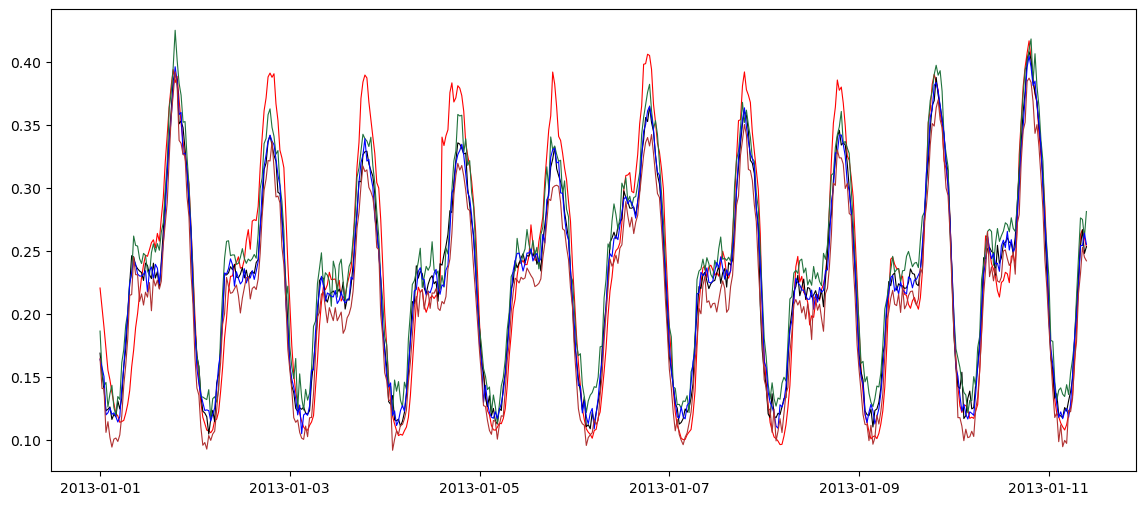

In [9]:
def simulate_data(mapping_prices, theta, context_map, prices,  Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2])):
    K = len(Gamma)
    sim = pd.concat([mapping_prices(prices), context_map], axis=1) @ theta + (prices * np.random.multivariate_normal(np.zeros(K), Gamma, len(prices))).mean(axis=1)
    sim = sim.to_frame(name='simulated_demand')
    sim.index.name = 'date_time'
    # clipping : demand must be positive
    sim['simulated_demand'] = sim['simulated_demand'].clip(lower=0) 
    return sim

sim = simulate_data(mapping_prices, theta, context_map, prices)
sim_Low = simulate_data(mapping_prices, theta, context_map, prices_Low)
sim_Normal = simulate_data(mapping_prices, theta, context_map, prices_Normal)
sim_High = simulate_data(mapping_prices, theta, context_map, prices_High)

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(phi.index[0:n], y[0:n], color='red', linewidth=0.8)
ax.plot(phi.index[0:n], sim[0:n], color='black', linewidth=0.8)
ax.plot(phi.index[0:n], sim_Low[0:n], color="#21733D", linewidth=0.8)
ax.plot(phi.index[0:n], sim_Normal[0:n], color='blue', linewidth=0.8)
ax.plot(phi.index[0:n], sim_High[0:n], color="#B03131", linewidth=0.8)
plt.show()

# remark : normal noise is not the best modelling (AR / variance per half-hour etc.)

In [10]:
# Assumption 1, constant definitions
Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2])
d = len(theta)
C = float(np.asarray(y.max()).squeeze())
G = float(np.asarray(Gamma.max()).squeeze())
gamma = G*2 
L = C**2 + G
delta = 0.01 

### Target Creation 

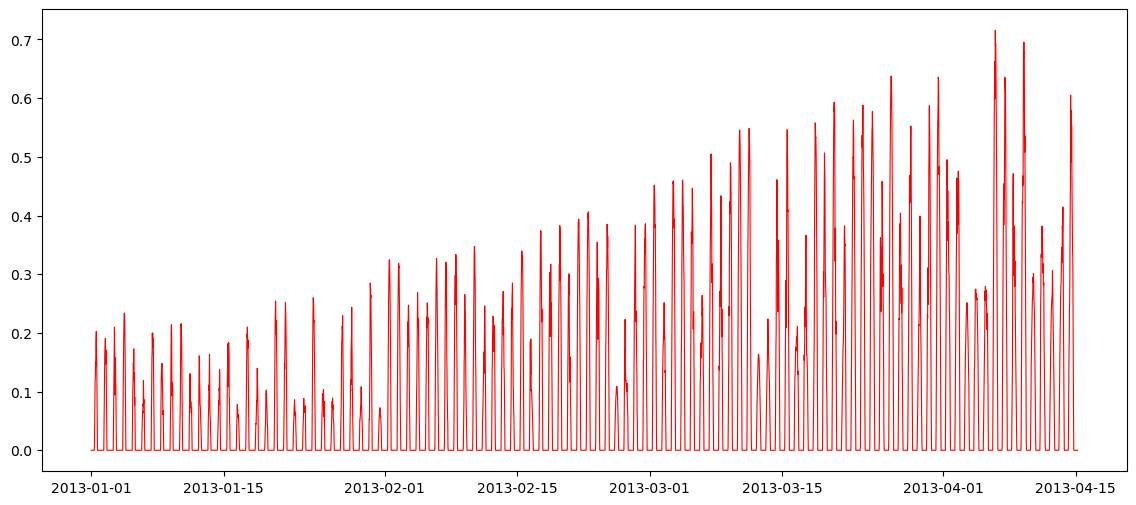

In [11]:
## https://pvpmc.sandia.gov and https://pvlib-python.readthedocs.io/en/v0.6.3/index.html
## pv_power = solar irradiance x area x efficiency 
## solar irradiance ~ GHI 
## remark : PV also depends on temperature

def pv_generation(ts_index, lat_deg = 51.507):   # London latitude (deg)
    doy = ts_index.dayofyear.to_numpy()
    hour = ts_index.hour.to_numpy() + ts_index.minute.to_numpy() / 60

    # Solar declination (Cooper formula)
    delta = np.deg2rad(23.44) * np.sin(2 * np.pi * (284 + doy) / 365)

    # Hour angle (relative to 12:00)
    H = np.deg2rad(360 * (hour - 12)/24)

    phi = np.deg2rad(lat_deg)

    # Angle of incidence
    # cos(theta) = sin(phi) sin(delta) + cos(phi) cos(delta) cos(H)
    cos_theta = np.sin(phi) * np.sin(delta) + np.cos(phi) * np.cos(delta) * np.cos(H)
    
    # Global Horizontal Irradiance. 
    # DNI (Direct normal irradiance) is equal to the extraterrestrial irradiance above the atmosphere minus the atmospheric losses due to absorption and scattering. Losses depend on time of day (length of light's path through the atmosphere depending on the solar elevation angle), cloud cover, moisture content and other contents. 
    # DHI (Direct horizontal irradiance ) is the radiation at the Earth's surface from light scattered by the atmosphere. It is measured on a horizontal surface with radiation coming from all points in the sky excluding circumsolar radiation (radiation coming from the sun disk). There would be almost no DHI in the absence of atmosphere
    # with no atmosphere
    DNI = 1367
    DHI = 0
    GHI = DNI * np.clip(cos_theta,0,1) + DHI

    # Cloud model 
    # Seasonal mean cloudiness (lower in summer)
    month_clear = {
        1: 0.25, 2: 0.30, 3: 0.40, 4: 0.50,
        5: 0.55, 6: 0.60, 7: 0.63, 8: 0.60,
        9: 0.48, 10: 0.40, 11: 0.32, 12: 0.25
    }
    base_clear = np.array([month_clear[m] for m in data.index.month.to_numpy()])

    # AR(1) cloud-smoothed noise
    cloud_latent = np.zeros(len(data.index))
    eps = np.random.standard_normal(len(data.index)) * 0.6
    rho = 0.96  # smoothness
    for i in range(1, len(data.index)):
        cloud_latent[i] = rho * cloud_latent[i-1] + eps[i]

    # Convert to transmissivity
    cloud_raw = 1 / (1 + np.exp(-cloud_latent))
    trans = 0.5 * cloud_raw + 0.5 * base_clear
    trans = np.clip(trans, 0.1, 0.95)

    # Final irradiance
    GHI = GHI * trans

    # PV power proportional to GHI 
    pv_profil = GHI/GHI.max()

    return pv_profil

pv_profil = pv_generation(data.index)

fig, ax = plt.subplots(figsize=(14, 6))
n = 5000
ax.plot(data.index[0:n], pv_profil[0:n], color='red', linewidth=0.8)
plt.show()

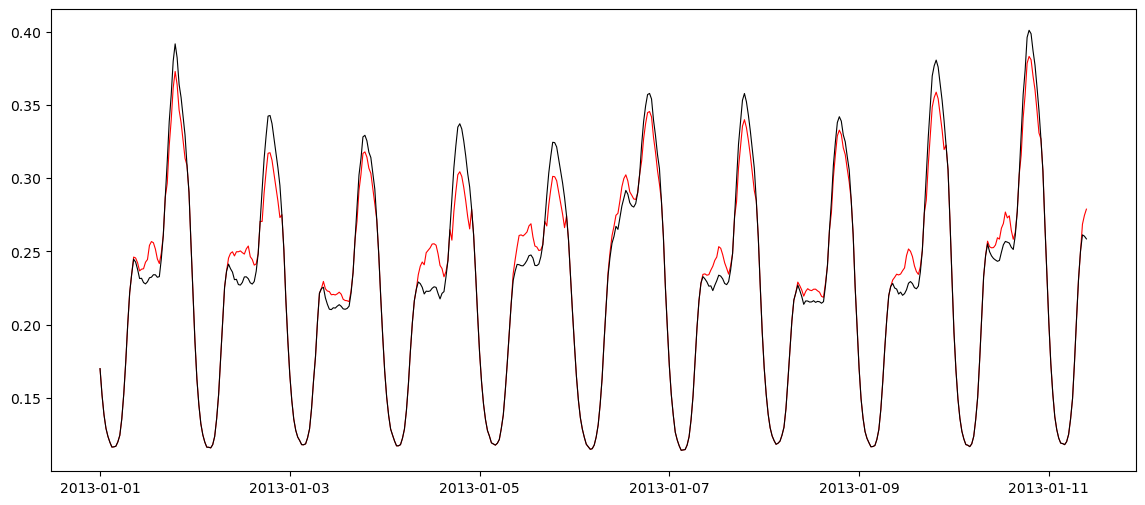

In [12]:
def create_target(forecast_Normal, prop=0.3, hh_start = 17*2, hh_end = 22*2): # prop = quantity of integrated pv, hh_start = 18:00, hh_end = 22:00 
    # maximum amount of integrated pv
    p = prop*forecast_Normal.max()
    pv_profil = pv_generation(forecast_Normal.index)

    target = forecast_Normal + pv_profil*p

    # reduction of the demand during peak hours to conserve of the electricity consummed per day (in mean = without noise)
    evening_mask_48 = (np.arange(48) >= hh_start) & (np.arange(48) < hh_end)

    dates = target.index.normalize()
    unique_days, day_idx = np.unique(dates.values, return_inverse=True)
    D = len(unique_days)

    target_d = target.values.reshape(D,48)
    y_d = forecast_Normal.values.reshape(D,48)

    S = y_d.sum(axis=1)    # original daily totals
    target_sum = target_d.sum(axis=1)       # after sunny uplift
    target_sum_peak = target_d[:, evening_mask_48].sum(axis=1)

    # (1 - p_e)*target_sum_peak + target_sum_non_peak = S  =>  p_e = (target_sum - S) / target_sum_peak
    p_e_raw = (target_sum - S) / target_sum_peak
    # clipping to keep a positive demand target
    p_e = np.clip(p_e_raw, 0.0, 1.0)


    target_d[:, evening_mask_48] *= (1.0 - p_e)[:, None]
    target = pd.Series(target_d.reshape(-1), index=forecast_Normal.index, name="target")
    return target

target = create_target(forecast_Normal)

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(target.index[0:n], target[0:n], color='red', linewidth=0.8)
ax.plot(data.index[0:n],  forecast_Normal[0:n], color='black', linewidth=0.8)
plt.show()


$p_t \in \underset{p\in\mathcal{P}}{\mathrm{argmin}} \{\hat{\ell}_{t,p} - \alpha_{t,p} \}$ 

$ \hat{\ell}_{t,p} = \big( [\phi(x_t,p)^\mathrm{T}\hat{\theta}_{t-1}]_C - c_t \big)^2 + p^\mathrm{T}\hat{\Gamma}p $

$ \alpha_{t,p} = \min\{L, 2CB_t(\delta t^{-2}) \|V_{t-1}^{-1/2} \phi(x_t,p)\| \} + \gamma$

In [13]:
def alpha(phi, V, C, L, t, lam, gamma=0,delta= 0.05):
    d = len(phi)
    # Cholesky for robustness 
    V_chol = np.linalg.cholesky(V)
    return np.clip(2*C*B(t+1, lam, d, C, rho, delta)*np.sqrt(np.sum(np.linalg.solve(V_chol, phi.values.T)**2, axis = 0)),0,L) + gamma
    # return np.clip(2*C*B(t+1, lam, d, C, rho, delta)*np.sqrt(np.diag(phi.values @ np.linalg.pinv(V) @ phi.values.T)),0,L) + gamma

def B(t, lam, d, C, rho, delta= 0.05):
    return float(np.sqrt(lam * d) * C) + rho * np.sqrt(2.0 * np.log((t ** 2) / delta) + d * np.log(1.0 + t / lam)) 

def loss(phi, hat_theta, target, C, p,  Gamma):
    return (np.clip((phi @ hat_theta),0,C) - target)**2 + np.diag(p @ Gamma @ p.T)

def grid(N):
    seg1 = np.arange(0, N + 1, dtype=float)              # (0:N)           length N+1
    seg2 = np.zeros(N, dtype=float)                      # rep(0, N)       length N
    seg3 = np.arange(N, -1, -1, dtype=float)             # (N:0)           length N+1
    seg4 = np.arange(0, N, dtype=float)                  # (0:(N-1))       length N
    seg5 = np.zeros(N + 1, dtype=float)                  # rep(0, N+1)     length N+1
    seg6 = np.arange(N, 0, -1, dtype=float)              # (N:1)           length N
    vec = np.concatenate([seg1, seg2, seg3, seg4, seg5, seg6])  # length 6N+3
    mat = np.reshape(vec, (2 * N + 1, 3), order='F')
    return mat / N

lam = 0.01
rho = np.sqrt(gamma)

As $\theta$ is a quite high-dimension vector, we assume, without loss of generality, that the coefficient related to context $x\in\mathcal{X}$ are kwown. The algorithm will only learn coefficient related to prices. 

In [14]:
def ucb(mapping_prices, simulate_data, context_map, theta_context, theta_prices,
        target, prices, C, Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]), delta = 0.05, K =3, N = 2, lam = 0.001, eta = 0.05):
    
    theta = pd.concat([theta_prices, theta_context])
    horizon = len(context_map)
    # initialization
    p = prices.copy()
    p['tariff_High'] = 0
    p['tariff_Normal'] = 0
    p['tariff_Low'] = 0
    p[['tariff_High', 'tariff_Normal', 'tariff_Low']] = p[['tariff_High', 'tariff_Normal', 'tariff_Low']].astype(float)

    # definition of \mathcal{P}
    p_grid = grid(N)
    p_all = p.copy().iloc[:len(p_grid),:]
    p_all['tariff_High'] = p_grid[:,0]
    p_all['tariff_Normal'] = p_grid[:,1]
    p_all['tariff_Low'] = p_grid[:,2]
    p_all = p_all.reset_index(drop=True)

    # random choice for first iteration 
    p.loc[p.index[0], np.random.choice(['tariff_High', 'tariff_Normal', 'tariff_Low'])] = 1
    
    # best strategy
    rep_context = pd.DataFrame(np.repeat(context_map[:1], len(p_all), axis = 0), columns=context_map.columns, index=p_all.index)
    phi_all = pd.concat([mapping_prices(p_all, rep_context), rep_context], axis=1)

    p_star = prices.copy()
    p_star['tariff_High'] = 0
    p_star['tariff_Normal'] = 0
    p_star['tariff_Low'] = 0
    p_star[['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_star[['tariff_High', 'tariff_Normal', 'tariff_Low']].astype(float)

    true_all = loss(phi_all, theta, target.iloc[0], C, p_all.to_numpy(),  Gamma)
    p_star.loc[p_star.index[0],['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_all.to_numpy()[true_all.idxmin(),:]

    demand = pd.DataFrame(index = context_map.index, columns = ['observed_demand', 'average_observed_demand', 'average_best_demand'])

    # observation of the demand 
    y_t = simulate_data(mapping_prices, theta, context_map[:1], p[:1], Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]))
    demand.loc[demand.index[0], 'observed_demand'] = y_t.values[0][0]

    y_mean = simulate_data(mapping_prices, theta, context_map[:1], p[:1],  Gamma = np.diag([0, 0, 0]))
    demand.loc[demand.index[0], 'average_observed_demand'] = y_mean.values[0][0]

    y_true = simulate_data(mapping_prices, theta, context_map[:1], p_star[:1],  Gamma = np.diag([0, 0, 0]))
    demand.loc[demand.index[0], 'average_best_demand'] = y_mean.values[0][0]

    # estimation of theta 
    phi_t_prices = mapping_prices(p[:1], context_map[:1])

    d = phi_t_prices.shape[1]
    V =  lam*np.diag(np.ones(d)) + phi_t_prices.T @ phi_t_prices 
    y_x_phi = (y_t.values[0][0] - (context_map[:1] @ theta_context).values[0])*phi_t_prices.values
    # Cholesky for robustness 
    V_chol = np.linalg.cholesky(V)
    hat_theta_prices = pd.Series(np.linalg.solve(V_chol.T, np.linalg.solve(V_chol, y_x_phi.T)).ravel(), index = theta_prices.index)
    hat_theta = pd.concat([hat_theta_prices, theta_context])


    for t in range(horizon-1):    
        #if t%48 == 0:
        #    print(t/48)
        #
        rep_context = pd.DataFrame(np.repeat(context_map[t+1:t+2], len(p_all), axis = 0), columns=context_map.columns, index=p_all.index)
        phi_all = pd.concat([mapping_prices(p_all, rep_context), rep_context], axis=1)         
        
        phi_all_prices = mapping_prices(p_all, rep_context)

        ucb_all = loss(phi_all, hat_theta, target.iloc[t+1], C, p_all.to_numpy(),  Gamma) - eta * alpha(phi_all_prices, V, C, L, t+1, lam, gamma, delta)
        true_all = loss(phi_all, theta, target.iloc[t+1], C, p_all.to_numpy(),  Gamma)

        #print(alpha(phi_all_prices, V, C, L, t+1, lam, gamma, delta))
        #print(loss(phi_all, hat_theta, target.iloc[t+1], C, p_all,  Gamma))
        
        # Prices choice 
        p.loc[p.index[t+1],['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_all.to_numpy()[ucb_all.idxmin(),:]
        p_star.loc[p_star.index[t+1],['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_all.to_numpy()[true_all.idxmin(),:]
        
        # Demand observation 
        y_t = simulate_data(mapping_prices, theta, context_map[t+1:t+2], p[t+1:t+2],  Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]))
        demand.loc[demand.index[t+1], 'observed_demand'] = y_t.values[0][0]

        y_mean = simulate_data(mapping_prices, theta, context_map[t+1:t+2], p[t+1:t+2],  Gamma = np.diag([0, 0, 0]))
        demand.loc[demand.index[t+1], 'average_observed_demand'] = y_mean.values[0][0]

        y_true = simulate_data(mapping_prices, theta, context_map[t+1:t+2], p_star[t+1:t+2],  Gamma = np.diag([0, 0, 0]))
        demand.loc[demand.index[t+1], 'average_best_demand'] = y_true.values[0][0]

        # Update theta estimation 
        phi_t_prices = mapping_prices(p[t+1:t+2], context_map[t+1:t+2])
        V =  V + + phi_t_prices.T @ phi_t_prices  
        y_x_phi = y_x_phi + (y_t.values[0][0] - (context_map[t+1:t+2] @ theta_context).values[0])*phi_t_prices.values
        V_chol = np.linalg.cholesky(V)
        hat_theta_prices = pd.Series(np.linalg.solve(V_chol.T, np.linalg.solve(V_chol, y_x_phi.T)).ravel(), index = theta_prices.index)
        hat_theta = pd.concat([hat_theta_prices, theta_context])
        #hat_theta = pd.Series(np.array(np.linalg.pinv(V)@(y_x_phi).T).ravel(), index = theta.index)
    return p, p_star, demand, hat_theta


In [15]:
p, p_star, demand, hat_theta = ucb(mapping_prices, simulate_data, context_map, theta_context, theta_prices,
        target, prices, C, Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]), delta = 0.05, K =3, N = 10, lam = 0.001, eta = 0.05)
    

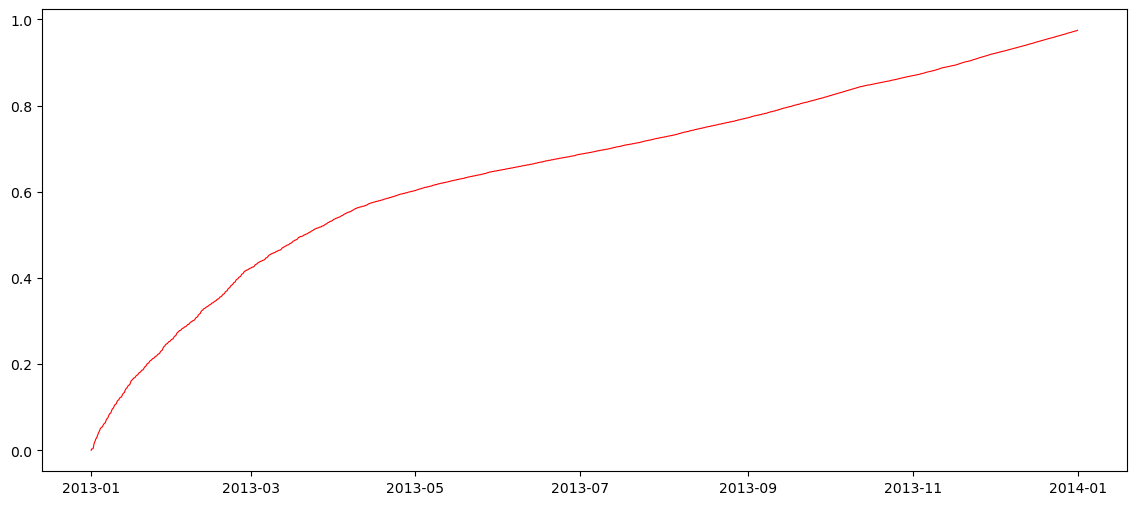

In [16]:
regret = (demand['average_observed_demand'] - target)**2 + np.diag(p.to_numpy() @ Gamma @ p.T.to_numpy()) -  ((demand['average_best_demand'] - target)**2 + np.diag(p_star.to_numpy() @ Gamma @ p_star.T.to_numpy()))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(target.index, np.cumsum(regret), color='red', linewidth=0.8)
plt.show()

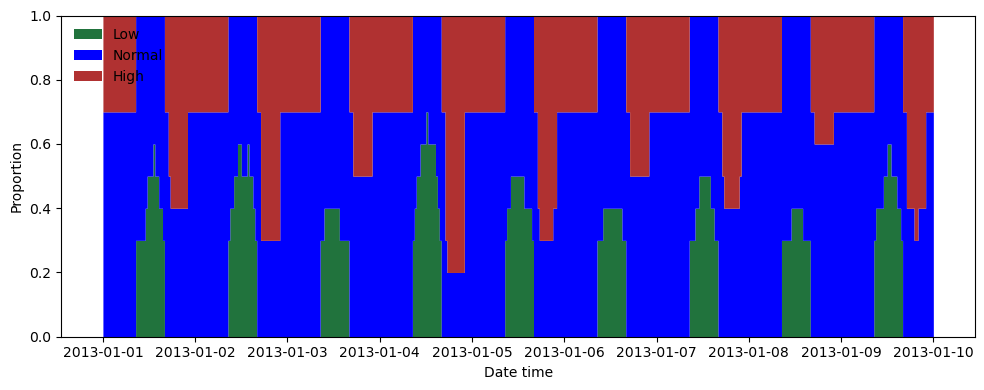

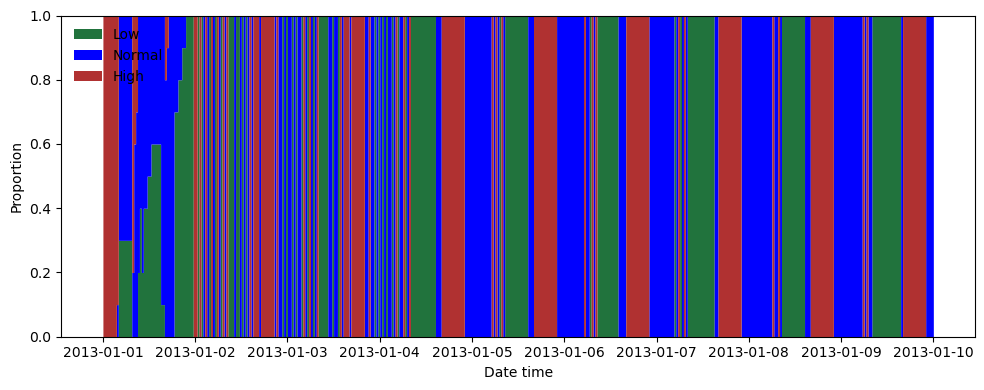

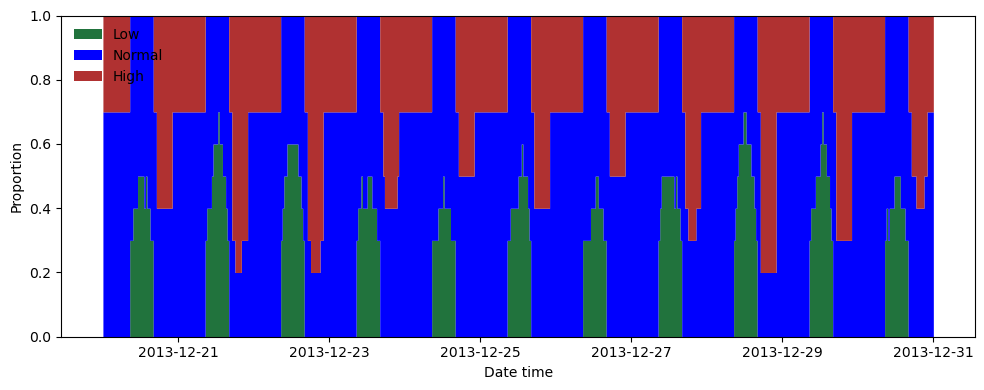

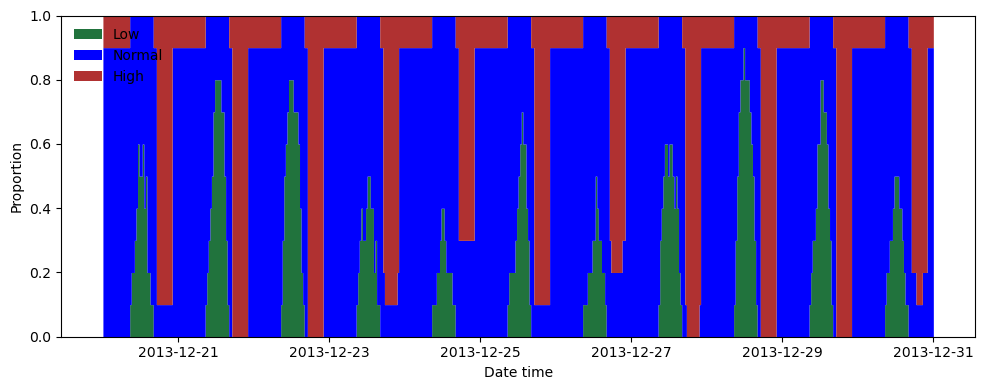

In [17]:
fig, ax = visualization_functions.plot_tariff_rectangle(p_star, start='2013-01-01 00:00:00', end='2013-01-10 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p,start='2013-01-01 00:00:00',end='2013-01-10 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p_star,start='2013-12-20 00:00:00',end='2013-12-31 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p,start='2013-12-20 00:00:00',end='2013-12-31 00:00:00')
plt.show()

Some remarks: 
- As usual, the theory is pessimistic.
- The target change favours exploration.

This is why we introduced the parameter $ \eta < 1$ to manually decrease the exploration, which is also legitimate given the overestimation of the constants $C$, $L$ etc.. 

## Robustness to the modelling (over simulators / real data)

MAPE:  2.65 %
RMSE:  65.0 (hWh/half-hour)



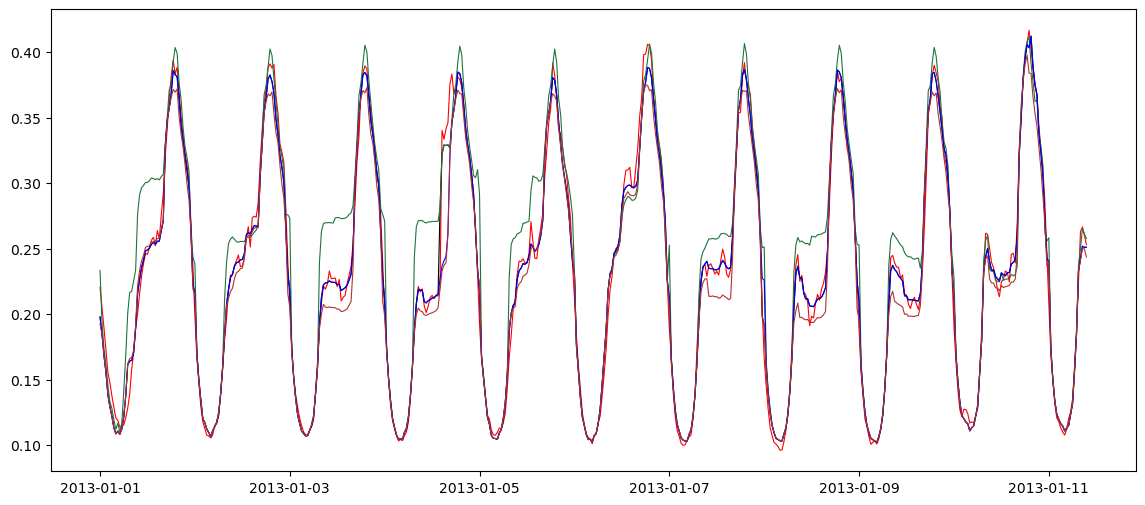

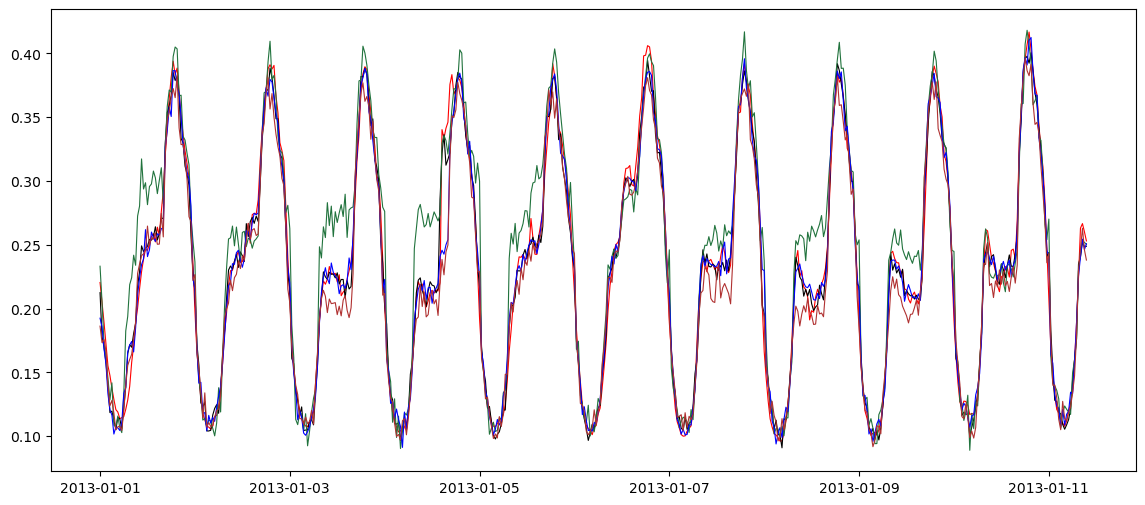

In [18]:
from sklearn.ensemble import RandomForestRegressor

def mapping_context_rf(context):
    # one-hot encoding of binary variables
    df = pd.concat([pd.get_dummies(context['day'], drop_first = True)*1,  
                     pd.get_dummies(context['half_hour'], prefix='half_hour', drop_first = True)*1], axis=1)
    
    # year_seasonality : with sosinus, 31 December and 1 January are next to each other.   
    df['year_seasonality'] = np.cos(2 * np.pi * np.arange(0, len(df))/ (365*48))

    # temperature inertia modeling
    def exp_smooth(vec, alpha):
        if alpha > 1 or alpha < 0:
            return 'alpha doit etre compris entre 0 et 1'
        else:
            smth = np.full(len(vec), np.nan)
            if len(vec) > 0:
                smth[0] = vec[0]
                if len(vec) > 1:
                    for i in range(1, len(vec)):
                        smth[i] = alpha * smth[i - 1] + (1 - alpha) * vec[i]
            return smth
        
    df['temperature'] = (context['temperature'])
    df['smoothed_temperature'] = exp_smooth(context['temperature'].to_numpy(), alpha= 0.998)    
    
    # potential non-linearity for temperature 
    df['heating_temperature2'] = (context['temperature'])**2 
    df['heating_heating'] = (context['temperature']<10)*(context['temperature'])
    df['heating_ac'] = (context['temperature']>20)*(context['temperature'])
    
    # temperature per half_hour 
    df_n = df.max(axis=0)
    return df/df_n

context_map_rf = mapping_context_rf(context)

X = pd.concat([prices, context_map_rf], axis = 1)
rf = RandomForestRegressor(n_estimators=100,  min_samples_split=10,  max_depth=50,  random_state=0)
rf.fit(X, y)
forecast_rf = rf.predict(X)
print('MAPE: ', round(mape(y, forecast_rf), 2), '%')
print('RMSE: ', round(rmse(y*1000, forecast_rf*1000),0), '(hWh/half-hour)\n')

forecast_Low_rf = rf.predict(pd.concat([prices_Low, context_map_rf], axis = 1))
forecast_Normal_rf = rf.predict(pd.concat([prices_Normal, context_map_rf], axis = 1))
forecast_High_rf = rf.predict(pd.concat([prices_High, context_map_rf], axis = 1))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(phi.index[0:n], y[0:n], color='red', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_rf[0:n], color='black', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_Low_rf[0:n], color="#21733D", linewidth=0.8)
ax.plot(phi.index[0:n], forecast_Normal_rf[0:n], color='blue', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_High_rf[0:n], color="#B03131", linewidth=0.8)
plt.show()

def simulate_data_rf(rf, context_map, prices,  Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2])):
    K = len(Gamma)
    sim = rf.predict(pd.concat([prices, context_map], axis = 1)) + (prices * np.random.multivariate_normal(np.zeros(K), Gamma, len(prices))).mean(axis=1)
    sim = sim.to_frame(name='simulated_demand')
    sim.index.name = 'date_time'
    # clipping : demand must be positive
    sim['simulated_demand'] = sim['simulated_demand'].clip(lower=0) 
    return sim

sim = simulate_data_rf(rf, context_map_rf, prices)
sim_Low = simulate_data_rf(rf, context_map_rf, prices_Low)
sim_Normal = simulate_data_rf(rf, context_map_rf, prices_Normal)
sim_High = simulate_data_rf(rf, context_map_rf, prices_High)

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(phi.index[0:n], y[0:n], color='red', linewidth=0.8)
ax.plot(phi.index[0:n], sim[0:n], color='black', linewidth=0.8)
ax.plot(phi.index[0:n], sim_Low[0:n], color="#21733D", linewidth=0.8)
ax.plot(phi.index[0:n], sim_Normal[0:n], color='blue', linewidth=0.8)
ax.plot(phi.index[0:n], sim_High[0:n], color="#B03131", linewidth=0.8)
plt.show()

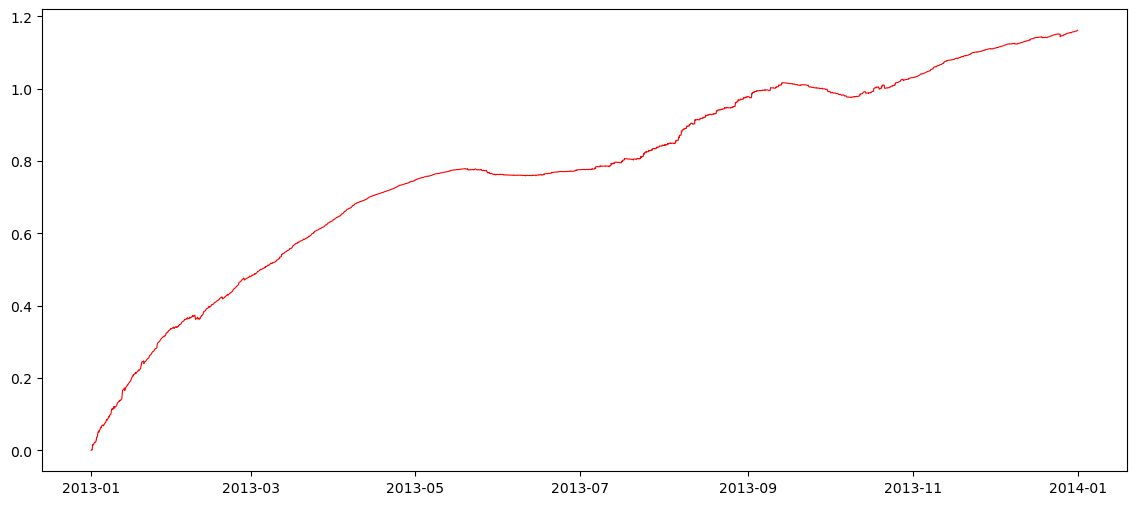

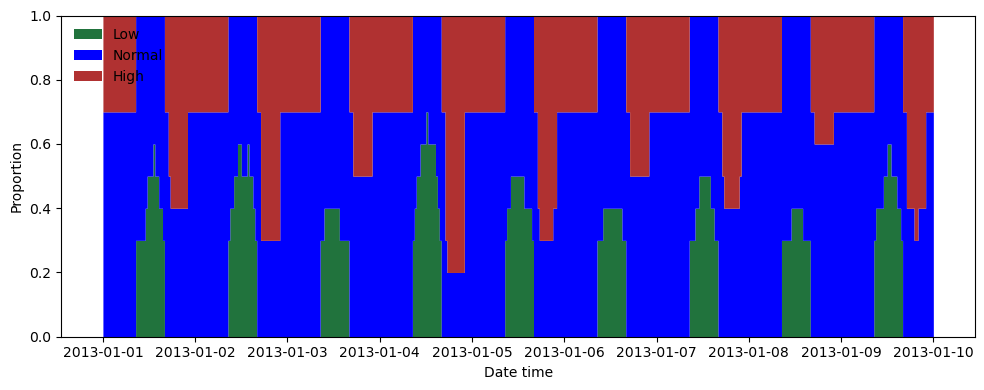

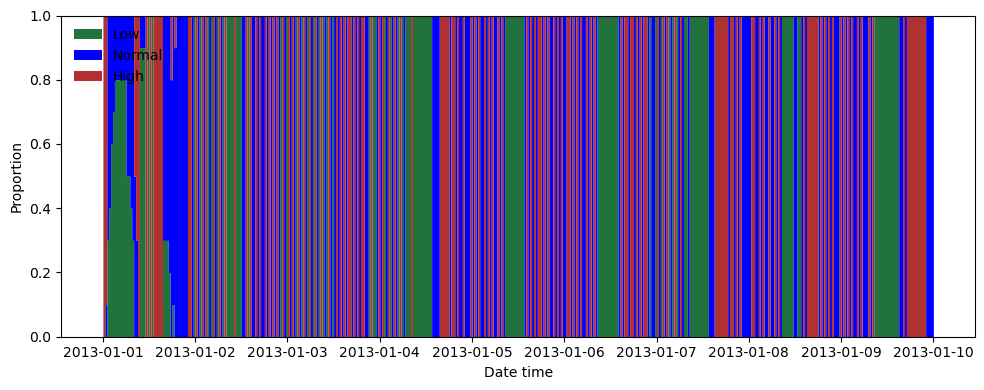

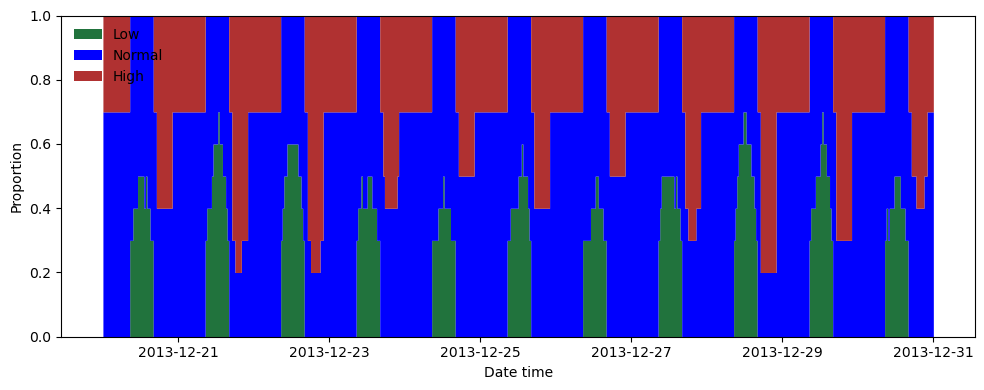

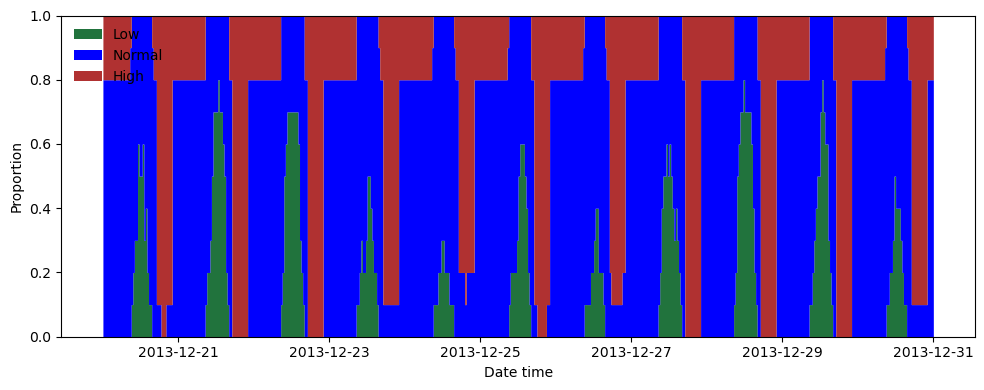

In [19]:
def ucb_rf(mapping_prices, simulate_data_rf, context_map, context_map_rf, theta_context, theta_prices,
        target, prices, C, Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]), delta = 0.05, K =3, N = 2, lam = 0.001, eta = 0.05):
    
    theta = pd.concat([theta_prices, theta_context])
    horizon = len(context_map)
    # initialization
    p = prices.copy()
    p['tariff_High'] = 0
    p['tariff_Normal'] = 0
    p['tariff_Low'] = 0
    p[['tariff_High', 'tariff_Normal', 'tariff_Low']] = p[['tariff_High', 'tariff_Normal', 'tariff_Low']].astype(float)

    # definition of \mathcal{P}
    p_grid = grid(N)
    p_all = p.copy().iloc[:len(p_grid),:]
    p_all['tariff_High'] = p_grid[:,0]
    p_all['tariff_Normal'] = p_grid[:,1]
    p_all['tariff_Low'] = p_grid[:,2]
    p_all = p_all.reset_index(drop=True)

    # random choice for first iteration 
    p.loc[p.index[0], np.random.choice(['tariff_High', 'tariff_Normal', 'tariff_Low'])] = 1
    
    # best strategy
    rep_context = pd.DataFrame(np.repeat(context_map[:1], len(p_all), axis = 0), columns=context_map.columns, index=p_all.index)
    phi_all = pd.concat([mapping_prices(p_all, rep_context), rep_context], axis=1)

    p_star = prices.copy()
    p_star['tariff_High'] = 0
    p_star['tariff_Normal'] = 0
    p_star['tariff_Low'] = 0
    p_star[['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_star[['tariff_High', 'tariff_Normal', 'tariff_Low']].astype(float)

    true_all = loss(phi_all, theta, target.iloc[0], C, p_all.to_numpy(),  Gamma)
    p_star.loc[p_star.index[0],['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_all.to_numpy()[true_all.idxmin(),:]

    demand = pd.DataFrame(index = context_map.index, columns = ['observed_demand', 'average_observed_demand', 'average_best_demand'])

    # observation of the demand 
    y_t = simulate_data_rf(rf, context_map_rf[:1], p[:1], Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]))
    demand.loc[demand.index[0], 'observed_demand'] = y_t.values[0][0]

    y_mean = simulate_data_rf(rf, context_map_rf[:1], p[:1],  Gamma = np.diag([0, 0, 0]))
    demand.loc[demand.index[0], 'average_observed_demand'] = y_mean.values[0][0]

    y_true = simulate_data_rf(rf, context_map_rf[:1], p_star[:1],  Gamma = np.diag([0, 0, 0]))
    demand.loc[demand.index[0], 'average_best_demand'] = y_mean.values[0][0]

    # estimation of theta 
    phi_t_prices = mapping_prices(p[:1], context_map[:1])

    d = phi_t_prices.shape[1]
    V =  lam*np.diag(np.ones(d)) + phi_t_prices.T @ phi_t_prices 
    y_x_phi = (y_t.values[0][0] - (context_map[:1] @ theta_context).values[0])*phi_t_prices.values
    # Cholesky for robustness 
    V_chol = np.linalg.cholesky(V)
    hat_theta_prices = pd.Series(np.linalg.solve(V_chol.T, np.linalg.solve(V_chol, y_x_phi.T)).ravel(), index = theta_prices.index)
    hat_theta = pd.concat([hat_theta_prices, theta_context])


    for t in range(horizon-1):    
        #if t%48 == 0:
        #    print(t/48)
        #
        rep_context = pd.DataFrame(np.repeat(context_map[t+1:t+2], len(p_all), axis = 0), columns=context_map.columns, index=p_all.index)
        phi_all = pd.concat([mapping_prices(p_all, rep_context), rep_context], axis=1)         
        
        phi_all_prices = mapping_prices(p_all, rep_context)

        ucb_all = loss(phi_all, hat_theta, target.iloc[t+1], C, p_all.to_numpy(),  Gamma) - eta * alpha(phi_all_prices, V, C, L, t+1, lam, gamma, delta)
        true_all = loss(phi_all, theta, target.iloc[t+1], C, p_all.to_numpy(),  Gamma)

        #print(alpha(phi_all_prices, V, C, L, t+1, lam, gamma, delta))
        #print(loss(phi_all, hat_theta, target.iloc[t+1], C, p_all,  Gamma))
        
        # Prices choice 
        p.loc[p.index[t+1],['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_all.to_numpy()[ucb_all.idxmin(),:]
        p_star.loc[p_star.index[t+1],['tariff_High', 'tariff_Normal', 'tariff_Low']] = p_all.to_numpy()[true_all.idxmin(),:]
        
        # Demand observation 
        y_t = simulate_data_rf(rf, context_map_rf[t+1:t+2], p[t+1:t+2],  Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]))
        demand.loc[demand.index[t+1], 'observed_demand'] = y_t.values[0][0]

        y_mean = simulate_data_rf(rf, context_map_rf[t+1:t+2], p[t+1:t+2],  Gamma = np.diag([0, 0, 0]))
        demand.loc[demand.index[t+1], 'average_observed_demand'] = y_mean.values[0][0]

        y_true = simulate_data_rf(rf, context_map_rf[t+1:t+2], p_star[t+1:t+2],  Gamma = np.diag([0, 0, 0]))
        demand.loc[demand.index[t+1], 'average_best_demand'] = y_true.values[0][0]

        # Update theta estimation 
        phi_t_prices = mapping_prices(p[t+1:t+2], context_map[t+1:t+2])
        V =  V + + phi_t_prices.T @ phi_t_prices  
        y_x_phi = y_x_phi + (y_t.values[0][0] - (context_map[t+1:t+2] @ theta_context).values[0])*phi_t_prices.values
        V_chol = np.linalg.cholesky(V)
        hat_theta_prices = pd.Series(np.linalg.solve(V_chol.T, np.linalg.solve(V_chol, y_x_phi.T)).ravel(), index = theta_prices.index)
        hat_theta = pd.concat([hat_theta_prices, theta_context])
        #hat_theta = pd.Series(np.array(np.linalg.pinv(V)@(y_x_phi).T).ravel(), index = theta.index)
    return p, p_star, demand, hat_theta


p, p_star, demand, hat_theta = ucb_rf(mapping_prices, simulate_data_rf, context_map, context_map_rf, theta_context, theta_prices,
        target, prices, C, Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]), delta = 0.05, K =3, N = 10, lam = 0.001, eta = 0.05)

regret = (demand['average_observed_demand'] - target)**2 + np.diag(p.to_numpy() @ Gamma @ p.T.to_numpy()) -  ((demand['average_best_demand'] - target)**2 + np.diag(p_star.to_numpy() @ Gamma @ p_star.T.to_numpy()))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(target.index, np.cumsum(regret), color='red', linewidth=0.8)
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p_star, start='2013-01-01 00:00:00', end='2013-01-10 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p,start='2013-01-01 00:00:00',end='2013-01-10 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p_star,start='2013-12-20 00:00:00',end='2013-12-31 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p,start='2013-12-20 00:00:00',end='2013-12-31 00:00:00')
plt.show()

# New price-demand relationship modelling 

In [20]:
def mapping_context(context):
    # one-hot encoding of binary variables
    df = pd.concat([context, 
                     pd.get_dummies(data['day'], drop_first = True)*1,  
                     pd.get_dummies(data['half_hour'], prefix='half_hour', drop_first = False)*1], axis=1).drop(['day','half_hour'], axis=1)
    
    # year_seasonality : with sosinus, 31 December and 1 January are next to each other.   
    df['year_seasonality'] = np.cos(2 * np.pi * np.arange(0, len(df))/ (365*48))

    # temperature inertia modeling
    def exp_smooth(vec, alpha):
        if alpha > 1 or alpha < 0:
            return 'alpha doit etre compris entre 0 et 1'
        else:
            smth = np.full(len(vec), np.nan)
            if len(vec) > 0:
                smth[0] = vec[0]
                if len(vec) > 1:
                    for i in range(1, len(vec)):
                        smth[i] = alpha * smth[i - 1] + (1 - alpha) * vec[i]
            return smth

    df['smoothed_temperature'] = exp_smooth(df['temperature'].to_numpy(), alpha= 0.998)    
    
    # potential non-linearity for temperature 
    df['heating_temperature2'] = (df['temperature'])**2 
    # df['heating_heating'] = (df['temperature']<10)*(df['temperature'])
    # df['heating_ac'] = (df['temperature']>20)*(df['temperature'])
    
    # temperature per half_hour 
    temp_by_halfhour = pd.get_dummies(data['half_hour'], prefix='temp_half_hour', drop_first=False).mul(data['temperature'], axis=0)
    df = pd.concat([df, temp_by_halfhour], axis=1).drop(['temperature'], axis=1)
    df_n = df.max(axis=0)
    return df/df_n

def mapping_prices_hh(prices, context_map):
    hh = context_map.loc[:, context_map.columns.str.startswith('half_hour_')]
    df = pd.concat([hh.add_prefix("High_").mul(prices.loc[:,'tariff_High'], axis='index'),          # explicit row-wise alignment,
                    hh.add_prefix("Normal_").mul(prices.loc[:,'tariff_Normal'], axis='index'),          # explicit row-wise alignment,
                    hh.add_prefix("Low_").mul(prices.loc[:,'tariff_Low'], axis='index')], axis = 1)         # explicit row-wise alignment], axis = 1)
    return df


MAPE:  7.68 %
RMSE:  387.0 (hWh/half-hour)



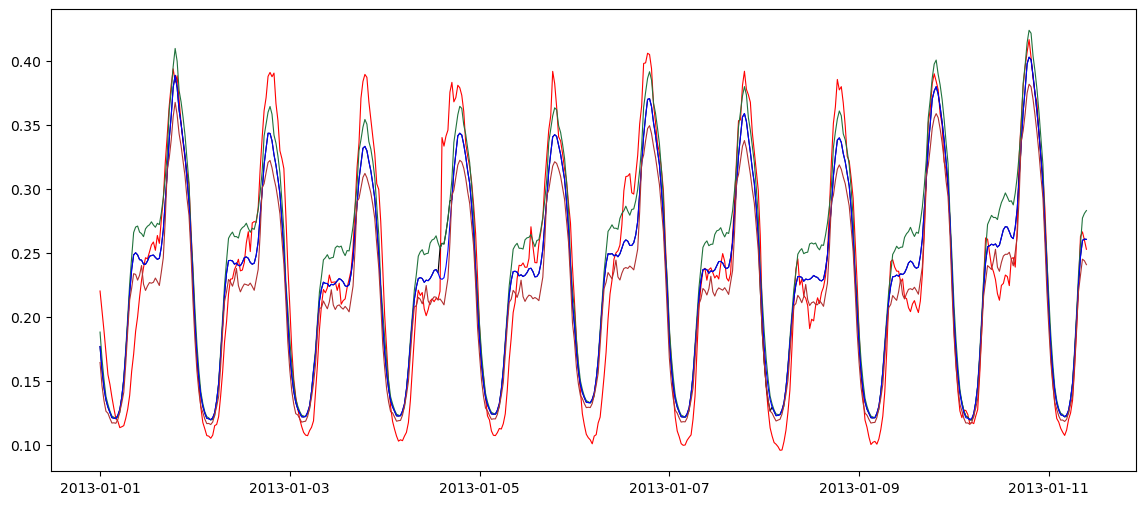

In [21]:
context_map = mapping_context(context)
phi = pd.concat([mapping_prices_hh(prices, context_map), context_map], axis=1)
y = data['demand'].to_numpy()
theta = np.linalg.pinv(phi.to_numpy()) @ y
theta = pd.Series(theta, index=phi.columns)
theta_context = theta[3*48:]
theta_prices = theta[:3*48]
forecast = phi @ theta
print('MAPE: ', round(mape(y, forecast), 2), '%')
print('RMSE: ', round(rmse(y*1000, forecast*1000),0), '(hWh/half-hour)\n')
prices_Low = prices.copy()
prices_Low['tariff_High'] = 0
prices_Low['tariff_Normal'] = 0
prices_Low['tariff_Low'] = 1

prices_Normal = prices.copy()
prices_Normal['tariff_High'] = 0
prices_Normal['tariff_Normal'] = 1
prices_Normal['tariff_Low'] = 0

prices_High = prices.copy()
prices_High['tariff_High'] = 1
prices_High['tariff_Normal'] = 0
prices_High['tariff_Low'] = 0

phi_Low = pd.concat([mapping_prices_hh(prices_Low, context_map), context_map], axis=1)
phi_Normal = pd.concat([mapping_prices_hh(prices_Normal,context_map), context_map], axis=1)
phi_High = pd.concat([mapping_prices_hh(prices_High,context_map), context_map], axis=1)

forecast_Low = phi_Low @ theta
forecast_Normal = phi_Normal @ theta
forecast_High = phi_High @ theta

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(phi.index[0:n], y[0:n], color='red', linewidth=0.8)
ax.plot(phi.index[0:n], forecast[0:n], color='black', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_Low[0:n], color="#21733D", linewidth=0.8)
ax.plot(phi.index[0:n], forecast_Normal[0:n], color='blue', linewidth=0.8)
ax.plot(phi.index[0:n], forecast_High[0:n], color="#B03131", linewidth=0.8)

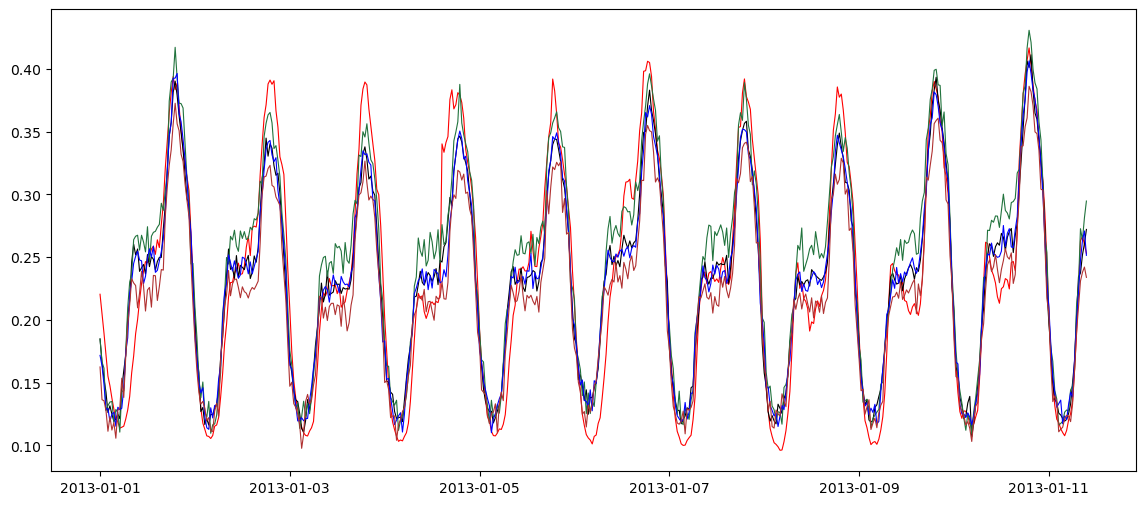

In [22]:
def simulate_data(mapping_prices_hh, theta, context_map, prices,  Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2])):
    K = len(Gamma)
    sim = pd.concat([mapping_prices_hh(prices, context_map), context_map], axis=1) @ theta + (prices * np.random.multivariate_normal(np.zeros(K), Gamma, len(prices))).mean(axis=1)
    sim = sim.to_frame(name='simulated_demand')
    sim.index.name = 'date_time'
    # clipping : demand must be positive
    sim['simulated_demand'] = sim['simulated_demand'].clip(lower=0) 
    return sim

sim = simulate_data(mapping_prices_hh, theta, context_map, prices)
sim_Low = simulate_data(mapping_prices_hh, theta, context_map, prices_Low)
sim_Normal = simulate_data(mapping_prices_hh, theta, context_map, prices_Normal)
sim_High = simulate_data(mapping_prices_hh, theta, context_map, prices_High)

fig, ax = plt.subplots(figsize=(14, 6))
n = 500
ax.plot(phi.index[0:n], y[0:n], color='red', linewidth=0.8)
ax.plot(phi.index[0:n], sim[0:n], color='black', linewidth=0.8)
ax.plot(phi.index[0:n], sim_Low[0:n], color="#21733D", linewidth=0.8)
ax.plot(phi.index[0:n], sim_Normal[0:n], color='blue', linewidth=0.8)
ax.plot(phi.index[0:n], sim_High[0:n], color="#B03131", linewidth=0.8)
plt.show()

In [23]:
target = create_target(forecast_Normal)
p, p_star, demand, hat_theta = ucb(mapping_prices_hh, simulate_data, context_map, theta_context, theta_prices,
        target, prices, C, Gamma = np.diag([std_High**2, std_Normal**2, std_Low**2]), delta = 0.05, K =3, N = 10, lam = 0.001, eta = 0.05)
    

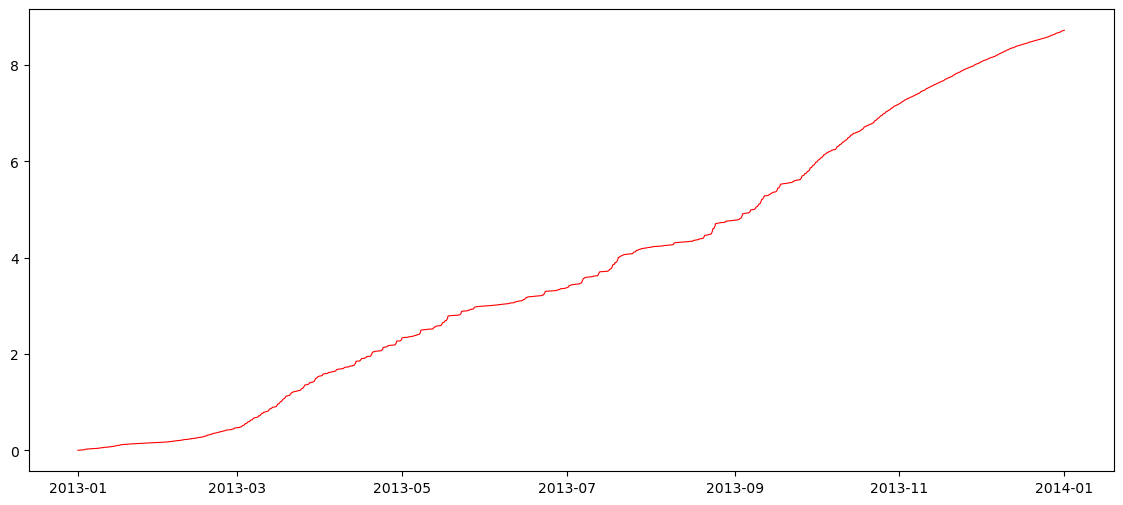

In [24]:
regret = (demand['average_observed_demand'] - target)**2 + np.diag(p.to_numpy() @ Gamma @ p.T.to_numpy()) -  ((demand['average_best_demand'] - target)**2 + np.diag(p_star.to_numpy() @ Gamma @ p_star.T.to_numpy()))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(target.index, np.cumsum(regret), color='red', linewidth=0.8)
plt.show()

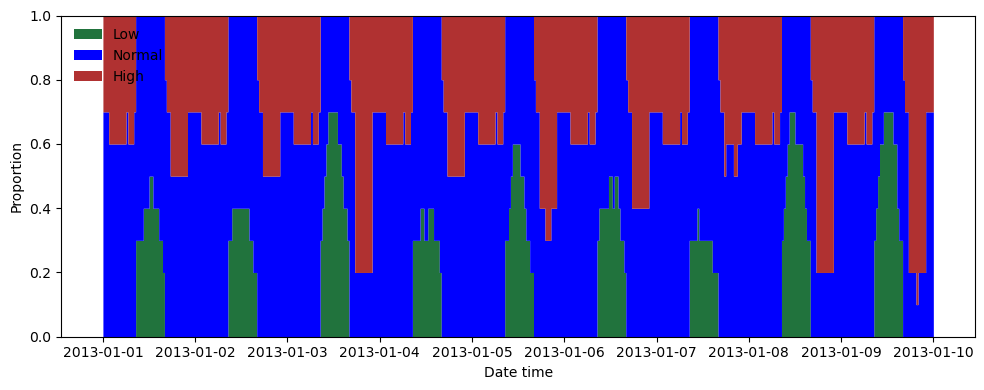

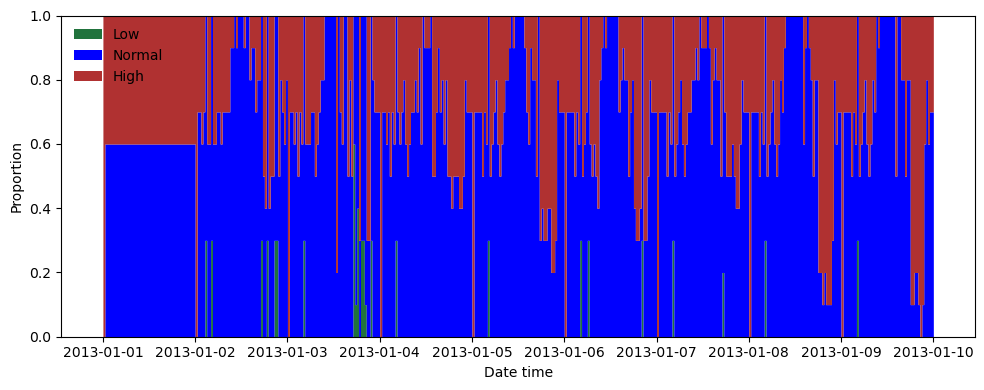

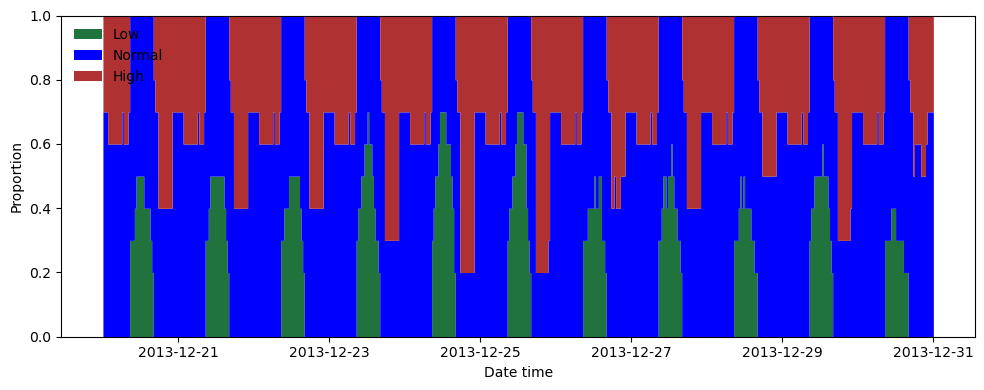

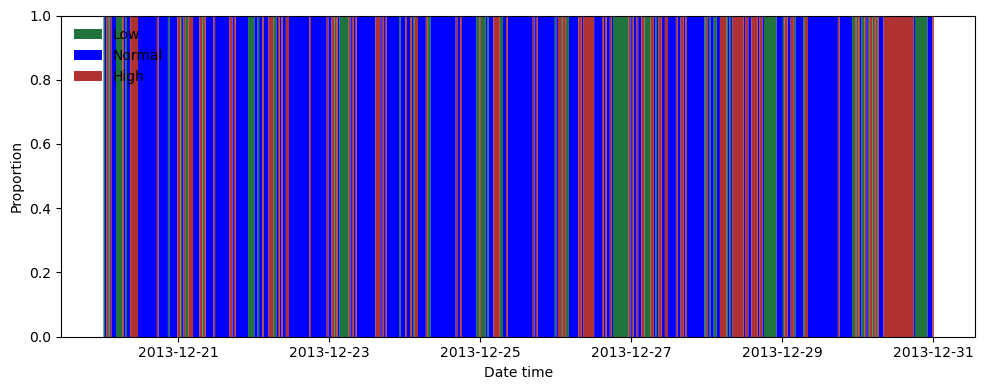

In [25]:
fig, ax = visualization_functions.plot_tariff_rectangle(p_star, start='2013-01-01 00:00:00', end='2013-01-10 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p,start='2013-01-01 00:00:00',end='2013-01-10 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p_star,start='2013-12-20 00:00:00',end='2013-12-31 00:00:00')
plt.show()

fig, ax = visualization_functions.plot_tariff_rectangle(p,start='2013-12-20 00:00:00',end='2013-12-31 00:00:00')
plt.show()